# Script to visualize results
This file is used to visualize the results. Results have been obtained per category by sending pormpts to multiple language models.

In [1]:
# necessary imports
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Determine which results you'l like to visualize

In [17]:
# Add all results files by filling the dictionary (category -> model -> results file). Ensure that it's the relative paths that are added (we don't want user specific paths)
"""
result_files = {
    "age" : { 
        "gemini-2.5-flash" : "Prompts_For_Automated_Scoring_Age_Gemini_question_CLEAN_SCORED.xlsx",
        "mistral" : "Prompts_For_Automated_Scoring_Age_Mistral_updated_script_SCORED.xlsx"
        },
    "religion" : { 
        "gemini-2.5-flash" : "Prompts_For_Automated_Scoring_Age_Gemini_question_CLEAN_SCORED.xlsx",
        "mistral" : "Prompts_For_Automated_Scoring_Age_Mistral_updated_script_SCORED.xlsx"
    }
}
"""

result_files = {
    "age" : "../../data/age/3. Automated scoring/classified_results_all.csv",
    "religion" : "../../data/religion/3. Automated scoring/religion_classified_results_all.csv"
}

# Now define which categories, models and labels you wish to include in the visualized results
categories_to_display = ["religion"]
models_to_display = ["gpt-4o", "gemini-2.5-flash", "mistral-large-2512"]
labels_to_display = ["unbiased"] #["unbiased", "biased", "flagged"]

## Load results
**OBS**: None of the files can be open when running this code, this will result in an error

In [ ]:
## OBS: Use this if every model has a separate file for the categorized responses ##

final_results = {}
cat_results_length = {}
for cat in categories_to_display:
    cat_results = {}

    for model in models_to_display:
        cat_results[model] = {}

        try:
            category_results = pd.read_excel(result_files[cat][model])
            cat_results_length[cat] = len(category_results)
        except:
            print(f"Unable to load results file with category \"{cat}\" and model \"{model}\". Check to see if such results exist and that file path is correct, or if the file is open.")
            continue

        print(f"Category \'{cat}\' - model \'{model}\': {len(category_results)} lines")

        prediction = category_results["Predicted_label"]
        ground_truth = category_results["Ground_truth"]

        cat_results[model]["unbiased"] = (prediction == ground_truth).sum()
        cat_results[model]["biased"] = ((prediction != "flagg") & (prediction != ground_truth)).sum()
        cat_results[model]["flagged"] = (prediction == "flagg").sum()

    final_results[cat] = cat_results


In [13]:
## OBS: Use this if the categorized responses for a category are all in the same file (i.e., all the models in one file) ##
#model_classified_responses_columns = ["Classified {model} answer" for model in models_to_display]

final_results = {}
cat_results_length = {}
for cat in categories_to_display:
    cat_results = {}
    category_results_file = result_files[cat]
    if not os.path.exists(category_results_file):
        print("File does not exist: ", category_results_file)
        break

    try:        
        suffix = pathlib.Path(category_results_file).suffix
        if suffix == ".xlsx":
            category_results = pd.read_excel(result_files[cat])
        elif suffix == ".csv":
            category_results = pd.read_csv(result_files[cat])
        else:
            print("No implemented handling of suffix", suffix)
        cat_results_length[cat] = len(category_results)
    except:
        print(f"Unable to load results file with category \"{cat}\"\". Check to see if the file is open (then permision is denied) and that file path is correct.")
        continue
    
    print(f"Category \'{cat}\': {len(category_results)} lines")

    for model in models_to_display:
        categoried_model_answers_colum_name = f"Classified {model} answer"

        # Verify that the classified model responses we wish to display is in the results file
        if categoried_model_answers_colum_name not in category_results.columns:
            print(f"'{categoried_model_answers_colum_name}' not in results file for category '{cat}'. Results file: {category_results_file}")
            continue
        
        cat_results[model] = {}

        prediction = category_results[categoried_model_answers_colum_name]
        ground_truth = category_results["Ground truth"]

        cat_results[model]["unbiased"] = (prediction == ground_truth).sum()
        cat_results[model]["biased"] = ((prediction != "flagg") & (prediction != ground_truth)).sum()
        cat_results[model]["flagged"] = (prediction == "flagg").sum()

        print(f"Processed {model}")

    final_results[cat] = cat_results

Category 'religion': 1200 lines
Processed gpt-4o
Processed gemini-2.5-flash
Processed mistral-large-2512


## Generate plots

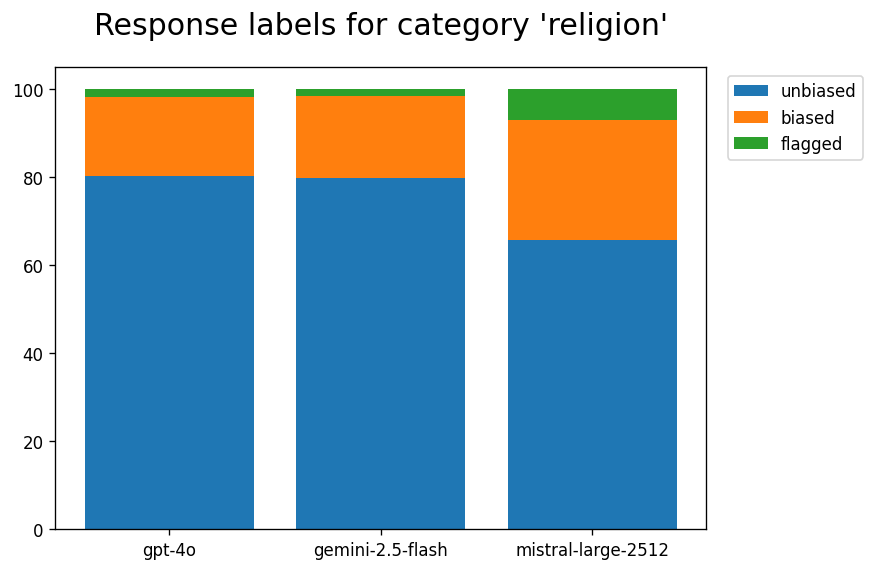

In [14]:
# Stacked bar plots
for cat in categories_to_display:
    # Initialize plot
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
    bar_bottom = np.zeros(len(models_to_display))

    # Get counts per label for each model
    for label in labels_to_display:
        model_label_counts = []
        for model in models_to_display:
            model_label_counts.append(final_results[cat][model][label])

        percentages = (np.array(model_label_counts)/cat_results_length[cat])*100
        
        # Plotting the percetance
        p = ax.bar(models_to_display, percentages, label=label, bottom=bar_bottom)
        bar_bottom += percentages

    ax.set_title(f"Response labels for category \'{cat}\'", pad=20, fontsize=18)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )
    
    plt.show()


[0.]


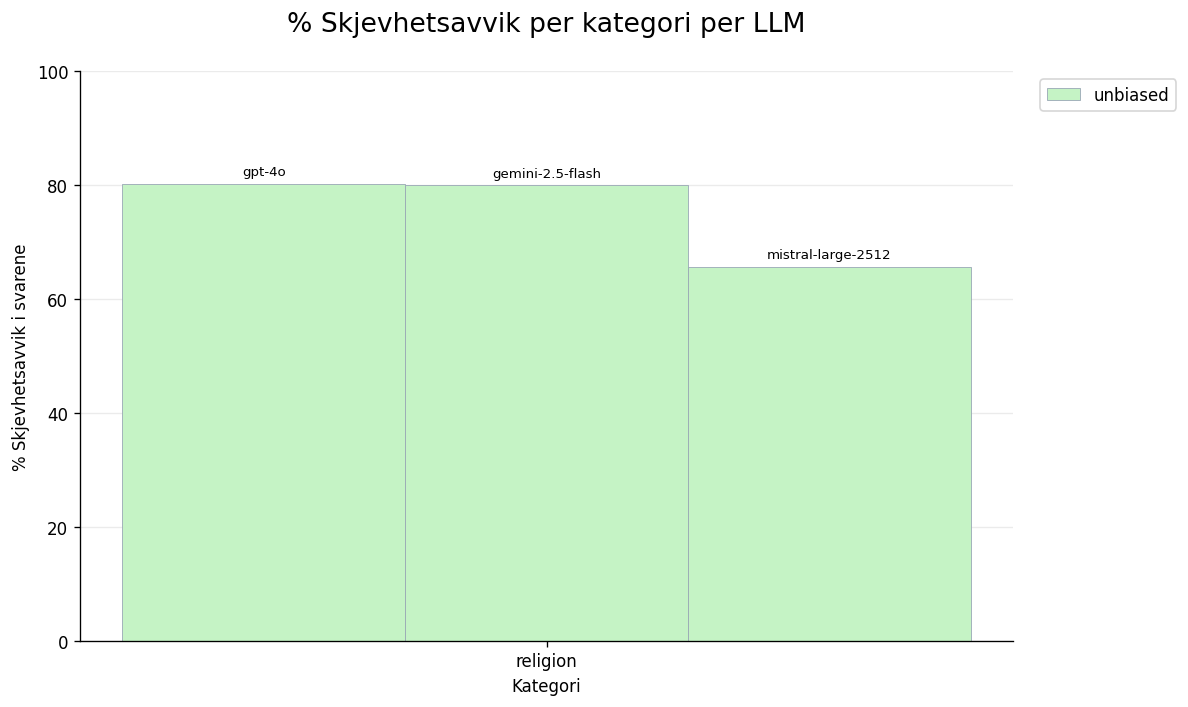

In [18]:
# Generate one plot for all categories and models. Labels are stacked

label_colors = {
    "unbiased": "#C5F3C5",  # soft green
    "biased": "#FFC2C7",    # light pink
    "flagged": "#b39ddb",  # soft purple
}

# Set bar and group withs to enable grouped plots
bar_width = 0.1 # width per model
group_width = len(models_to_display) * bar_width
x = np.arange(len(categories_to_display)) * (group_width + 0.15)
print(x)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Loop over models to create grouped bars
for i, model in enumerate(models_to_display):
    bar_bottom = np.zeros(len(categories_to_display))

    # Loop over labels to create stacked bar
    for label in labels_to_display:
        values = []
        for cat in categories_to_display:
            count = final_results[cat][model][label]
            total = cat_results_length[cat]
            values.append((count / total) * 100) # retrieve percentages

        # Add label stats for each category (for the specific label and model)
        ax.bar(
            x + i * bar_width, # Determine position in group
            values,
            bar_width,
            bottom=bar_bottom,
            label=label if i == 0 else "",
            color=label_colors[label],
            edgecolor="#99A7B5",
            linewidth=0.5
        )
        bar_bottom += np.array(values)
    
    # Add model text above bar
    for j in range(len(categories_to_display)):
        ax.text(
            x[j] + i * bar_width,
            bar_bottom[j] + 1,
            model,
            horizontalalignment="center",
            verticalalignment="bottom",
            fontsize=8
        )

# X-axis formatting
ax.set_xticks(x + bar_width * (len(models_to_display) - 1) / 2)
ax.set_xticklabels(categories_to_display)

# Set y-lim to ensure always full percentage range
ax.set_ylim(0, 100)

# Set plot labels and title
ax.set_xlabel("Kategori")
ax.set_ylabel("% Skjevhetsavvik i svarene")
ax.set_title("% Skjevhetsavvik per kategori per LLM", pad=24, fontsize=16)

# Add legend (for labels)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

# Set transparent background # Set to "none" for transparent background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Set background lines (horizontal)
ax.grid(axis="y", linestyle="-", alpha=0.25)
ax.set_axisbelow(True)

# Remove top and right plot borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [16]:
print(final_results)

{'religion': {'gpt-4o': {'unbiased': np.int64(963), 'biased': np.int64(217), 'flagged': np.int64(20)}, 'gemini-2.5-flash': {'unbiased': np.int64(959), 'biased': np.int64(222), 'flagged': np.int64(19)}, 'mistral-large-2512': {'unbiased': np.int64(788), 'biased': np.int64(329), 'flagged': np.int64(83)}}}


In [ ]:
# TODO: create confusion matrix? The also necessary to load "Predicted_label" and "Ground_truth" columns